# Exploratory Data Analysis
## AI Jobs & Salary Dashboard Project

This notebook performs the initial exploratory data analysis for the Data Mining project about the impact of Artificial Intelligence on jobs and salary trends.

### Goals
- Understand the dataset structure
- Check data quality
- Explore distributions and trends
- Analyze relationships between AI risk, salary, and job survival
- Generate insights for Phase 1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

## Load Dataset
Make sure the dataset CSV file is inside the `data` folder.

In [8]:
df = pd.read_csv("Future of Jobs AI Dataset.csv")
df.head()

,job_title,country,experience_level,education_level,year,salary,ai_risk_score,primary_skill,skill_demand_score,job_openings,job_survival_class,salary_bucket,ai_risk_category
0,Data Scientist,USA,Senior,Master,2022,61931.03,0.32,Python,88,39158,2,High,Medium Risk
1,Software Engineer,India,Senior,Bachelor,2032,21330.84,0.52,Java,80,7265,1,High,Medium Risk
2,Data Scientist,Canada,Mid,Bachelor,2015,24211.17,0.25,Python,70,22962,1,High,Low Risk
3,Data Scientist,India,Entry,PhD,2034,11794.86,0.44,Python,95,17023,1,Medium,Medium Risk
4,Data Analyst,Canada,Entry,PhD,2035,17999.26,0.75,SQL,61,3433,0,Medium,High Risk


## Basic Dataset Overview

In [9]:
print("Shape of dataset:", df.shape)

Shape of dataset: (12343, 13)


In [10]:
df.columns.tolist()

['job_title',
 'country',
 'experience_level',
 'education_level',
 'year',
 'salary',
 'ai_risk_score',
 'primary_skill',
 'skill_demand_score',
 'job_openings',
 'job_survival_class',
 'salary_bucket',
 'ai_risk_category']

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12343 entries, 0 to 12342
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   job_title           12343 non-null  object 
 1   country             12343 non-null  object 
 2   experience_level    12343 non-null  object 
 3   education_level     12343 non-null  object 
 4   year                12343 non-null  int64  
 5   salary              12343 non-null  float64
 6   ai_risk_score       12343 non-null  float64
 7   primary_skill       12343 non-null  object 
 8   skill_demand_score  12343 non-null  int64  
 9   job_openings        12343 non-null  int64  
 10  job_survival_class  12343 non-null  int64  
 11  salary_bucket       12343 non-null  object 
 12  ai_risk_category    12343 non-null  object 
dtypes: float64(2), int64(4), object(7)
memory usage: 1.2+ MB


In [12]:
df.describe()

,year,salary,ai_risk_score,skill_demand_score,job_openings,job_survival_class
count,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000,12343.000000
mean,2025.054525,34553.729166,0.396008,79.453374,25223.652029,1.310054
std,6.058714,18024.702961,0.187665,11.483535,14163.309081,0.658417
min,2015.000000,3875.170000,0.050000,60.000000,1002.000000,0.000000
25%,2020.000000,21331.405000,0.260000,70.000000,12993.000000,1.000000
50%,2025.000000,31573.380000,0.360000,79.000000,24896.000000,1.000000
75%,2030.000000,45307.845000,0.490000,89.000000,37440.500000,2.000000
max,2035.000000,113589.260000,0.850000,99.000000,49998.000000,2.000000


In [13]:
df.describe(include="object")

,job_title,country,experience_level,education_level,primary_skill,salary_bucket,ai_risk_category
count,12343,12343,12343,12343,12343,12343,12343
unique,10,6,3,3,9,3,3
top,Business Analyst,UK,Senior,Master,Python,High,Medium Risk
freq,1312,2145,4195,4146,2430,9594,6016


## Data Quality Check
We will inspect missing values and duplicated records.

In [14]:
df.isnull().sum()

job_title             0
country               0
experience_level      0
education_level       0
year                  0
salary                0
ai_risk_score         0
primary_skill         0
skill_demand_score    0
job_openings          0
job_survival_class    0
salary_bucket         0
ai_risk_category      0
dtype: int64

In [15]:
missing_percent = (df.isnull().sum() / len(df)) * 100
missing_percent

job_title             0.0
country               0.0
experience_level      0.0
education_level       0.0
year                  0.0
salary                0.0
ai_risk_score         0.0
primary_skill         0.0
skill_demand_score    0.0
job_openings          0.0
job_survival_class    0.0
salary_bucket         0.0
ai_risk_category      0.0
dtype: float64

In [16]:
print("Number of duplicated rows:", df.duplicated().sum())

Number of duplicated rows: 0


## Data Types

In [17]:
df.dtypes

job_title              object
country                object
experience_level       object
education_level        object
year                    int64
salary                float64
ai_risk_score         float64
primary_skill          object
skill_demand_score      int64
job_openings            int64
job_survival_class      int64
salary_bucket          object
ai_risk_category       object
dtype: object

## Numerical Columns Distribution

In [18]:
num_cols = ["year", "salary", "ai_risk_score", "skill_demand_score", "job_openings"]

existing_num_cols = [col for col in num_cols if col in df.columns]
existing_num_cols

['year', 'salary', 'ai_risk_score', 'skill_demand_score', 'job_openings']

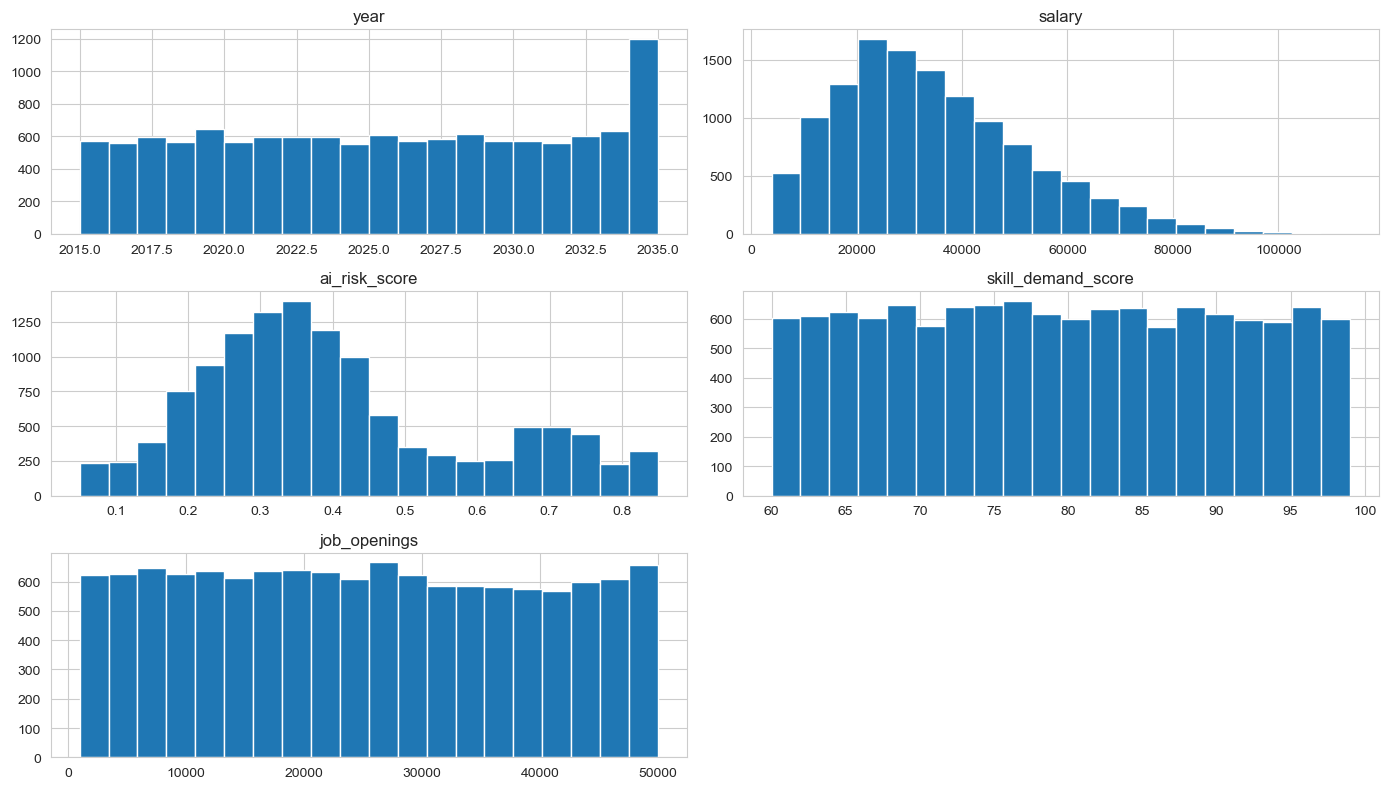

In [19]:
df[existing_num_cols].hist(bins=20, figsize=(14, 8))
plt.tight_layout()
plt.show()

## Categorical Columns Overview

In [20]:
cat_cols = ["job_title", "country", "experience_level", "education_level", "primary_skill"]

for col in cat_cols:
    if col in df.columns:
        print(f"\nValue counts for {col}")
        print(df[col].value_counts())


Value counts for job_title
job_title
Business Analyst         1312
Data Analyst             1293
Cloud Engineer           1273
Software Engineer        1252
Product Manager          1247
Data Scientist           1225
Cybersecurity Analyst    1209
AI Researcher            1209
ML Engineer              1205
DevOps Engineer          1118
Name: count, dtype: int64

Value counts for country
country
UK           2145
Australia    2080
USA          2064
Germany      2044
Canada       2021
India        1989
Name: count, dtype: int64

Value counts for experience_level
experience_level
Senior    4195
Entry     4075
Mid       4073
Name: count, dtype: int64

Value counts for education_level
education_level
Master      4146
PhD         4104
Bachelor    4093
Name: count, dtype: int64

Value counts for primary_skill
primary_skill
Python           2430
Excel            1312
SQL              1293
AWS              1273
Java             1252
Strategy         1247
Security         1209
Deep Learning    1

## Jobs by Country

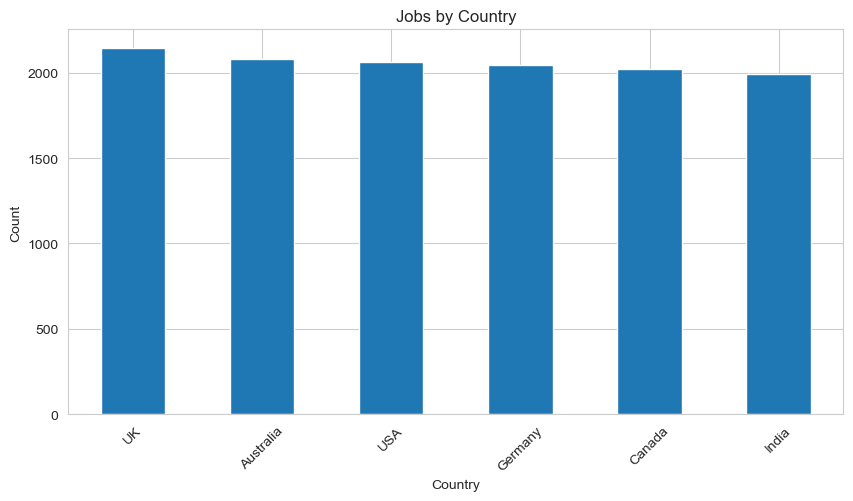

In [21]:
if "country" in df.columns:
    df["country"].value_counts().plot(kind="bar")
    plt.title("Jobs by Country")
    plt.xlabel("Country")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## Jobs by Job Title

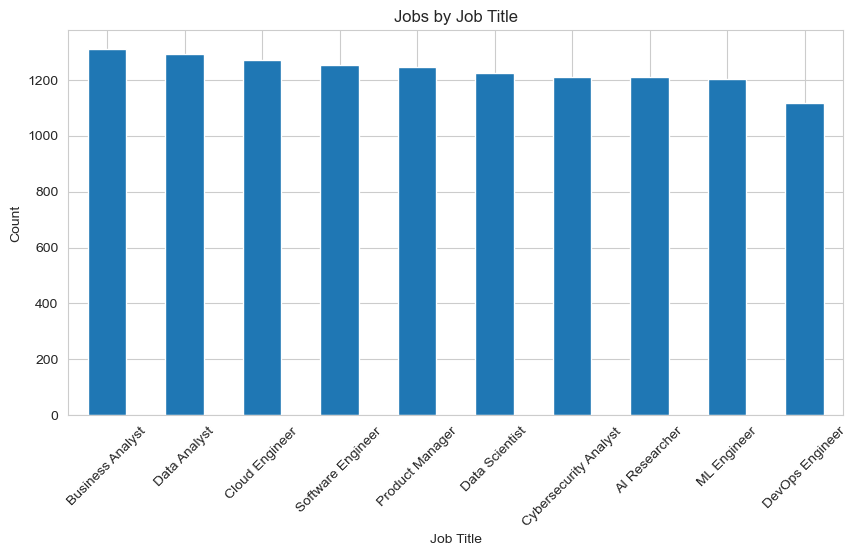

In [22]:
if "job_title" in df.columns:
    df["job_title"].value_counts().plot(kind="bar")
    plt.title("Jobs by Job Title")
    plt.xlabel("Job Title")
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

## Jobs by Experience Level

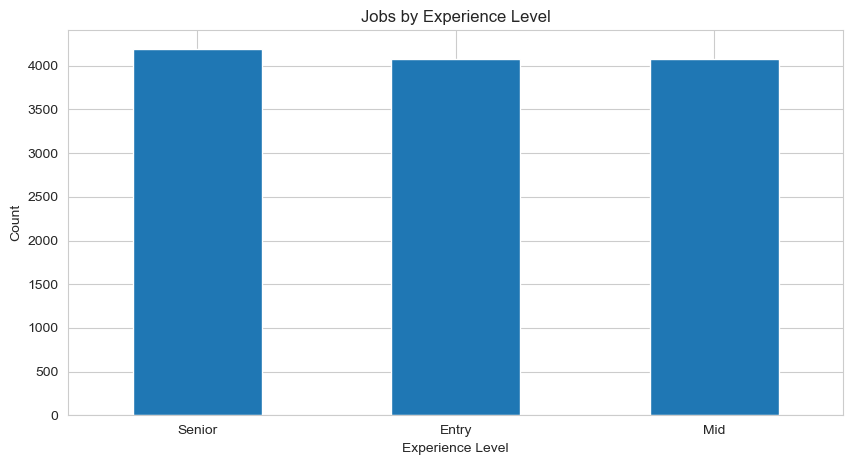

In [23]:
if "experience_level" in df.columns:
    df["experience_level"].value_counts().plot(kind="bar")
    plt.title("Jobs by Experience Level")
    plt.xlabel("Experience Level")
    plt.ylabel("Count")
    plt.xticks(rotation=0)
    plt.show()

## Target Variable Analysis
### Job Survival Class

In [24]:
if "job_survival_class" in df.columns:
    print(df["job_survival_class"].value_counts())

job_survival_class
1    5806
2    5182
0    1355
Name: count, dtype: int64


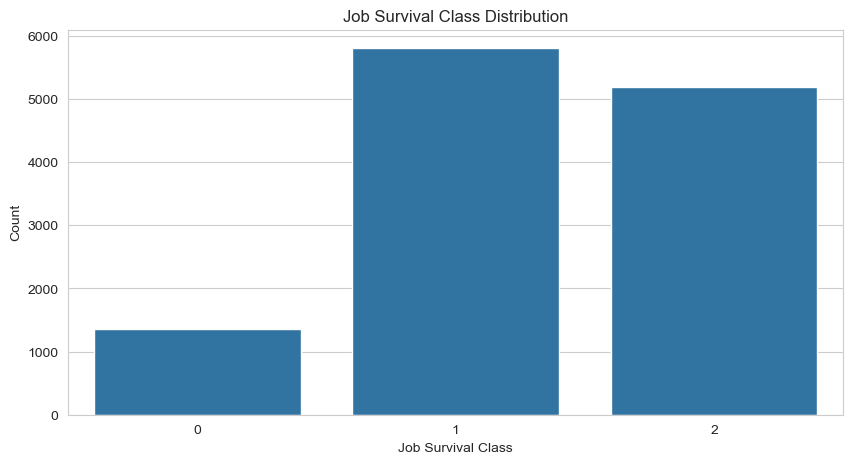

In [25]:
if "job_survival_class" in df.columns:
    sns.countplot(data=df, x="job_survival_class")
    plt.title("Job Survival Class Distribution")
    plt.xlabel("Job Survival Class")
    plt.ylabel("Count")
    plt.show()

### Salary Distribution

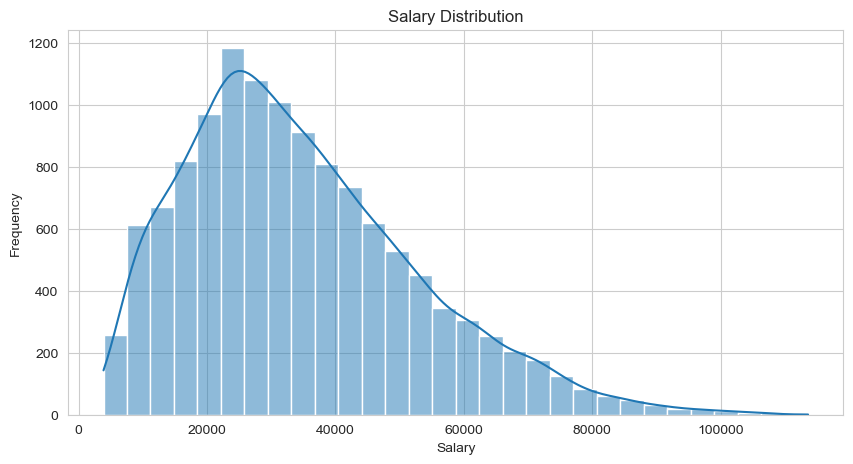

In [26]:
if "salary" in df.columns:
    sns.histplot(df["salary"], kde=True, bins=30)
    plt.title("Salary Distribution")
    plt.xlabel("Salary")
    plt.ylabel("Frequency")
    plt.show()

## AI Risk Score Distribution

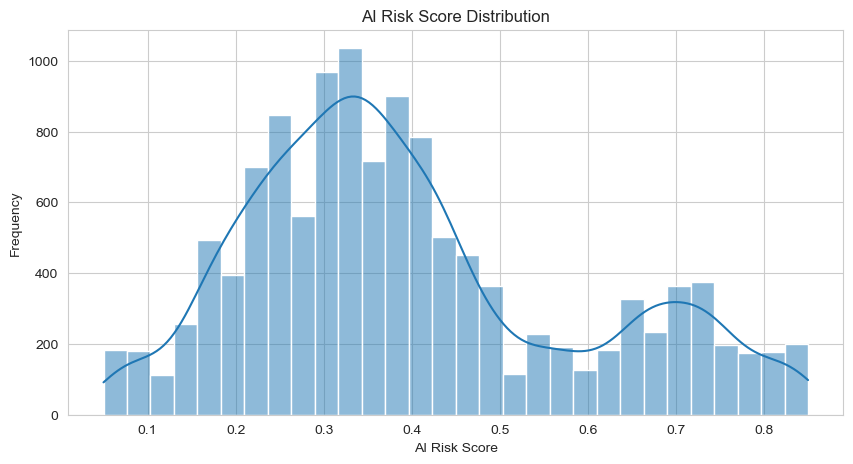

In [27]:
if "ai_risk_score" in df.columns:
    sns.histplot(df["ai_risk_score"], kde=True, bins=30)
    plt.title("AI Risk Score Distribution")
    plt.xlabel("AI Risk Score")
    plt.ylabel("Frequency")
    plt.show()

## Relationship Between Salary and AI Risk Score

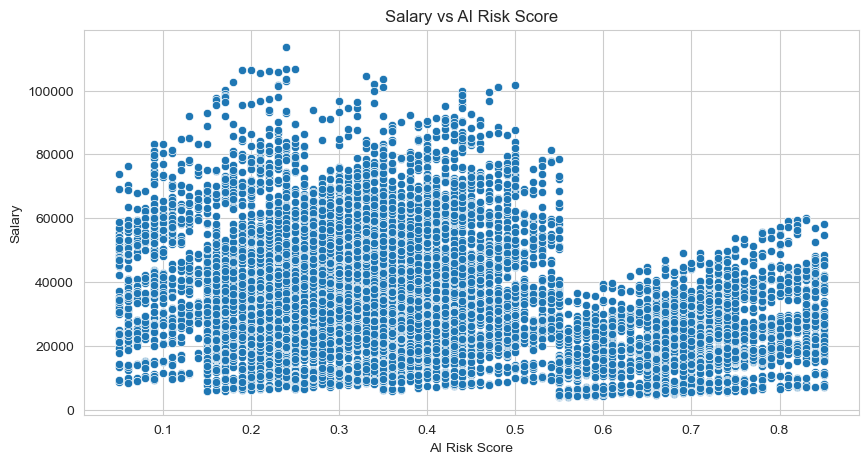

In [28]:
if "salary" in df.columns and "ai_risk_score" in df.columns:
    sns.scatterplot(data=df, x="ai_risk_score", y="salary")
    plt.title("Salary vs AI Risk Score")
    plt.xlabel("AI Risk Score")
    plt.ylabel("Salary")
    plt.show()

## Salary by Experience Level

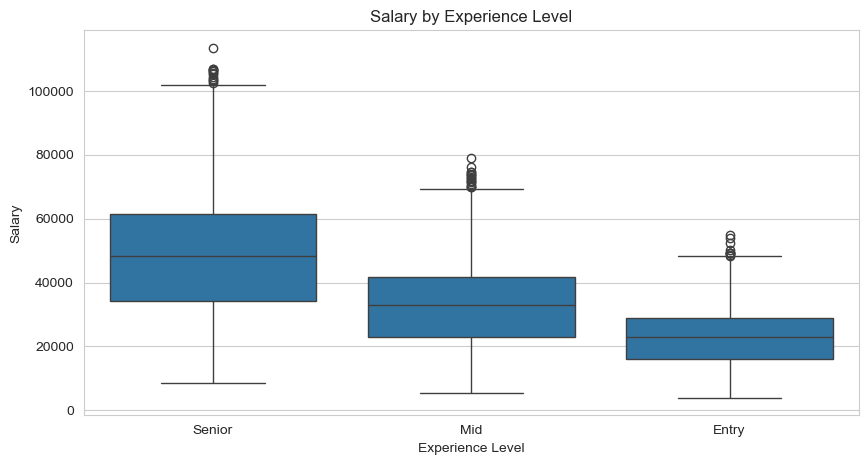

In [29]:
if "experience_level" in df.columns and "salary" in df.columns:
    sns.boxplot(data=df, x="experience_level", y="salary")
    plt.title("Salary by Experience Level")
    plt.xlabel("Experience Level")
    plt.ylabel("Salary")
    plt.show()

## Salary by Country

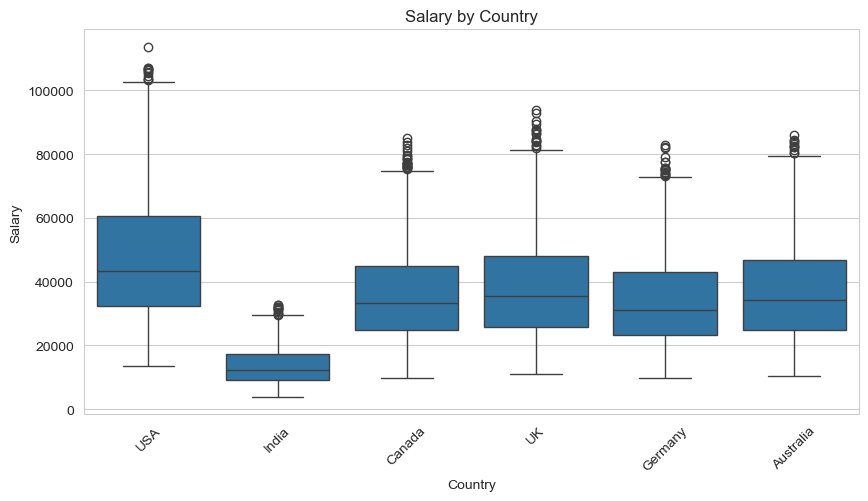

In [30]:
if "country" in df.columns and "salary" in df.columns:
    sns.boxplot(data=df, x="country", y="salary")
    plt.title("Salary by Country")
    plt.xlabel("Country")
    plt.ylabel("Salary")
    plt.xticks(rotation=45)
    plt.show()

## AI Risk Score by Job Title

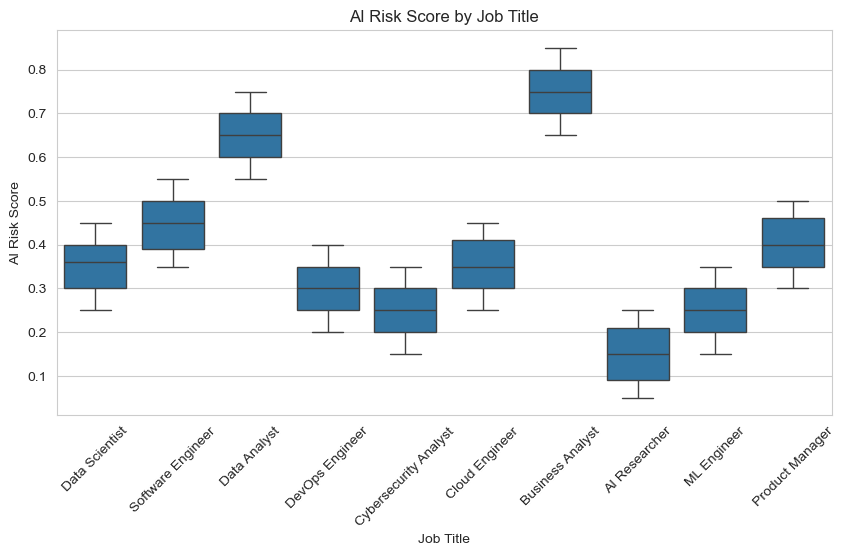

In [31]:
if "job_title" in df.columns and "ai_risk_score" in df.columns:
    sns.boxplot(data=df, x="job_title", y="ai_risk_score")
    plt.title("AI Risk Score by Job Title")
    plt.xlabel("Job Title")
    plt.ylabel("AI Risk Score")
    plt.xticks(rotation=45)
    plt.show()

## Salary by Education Level

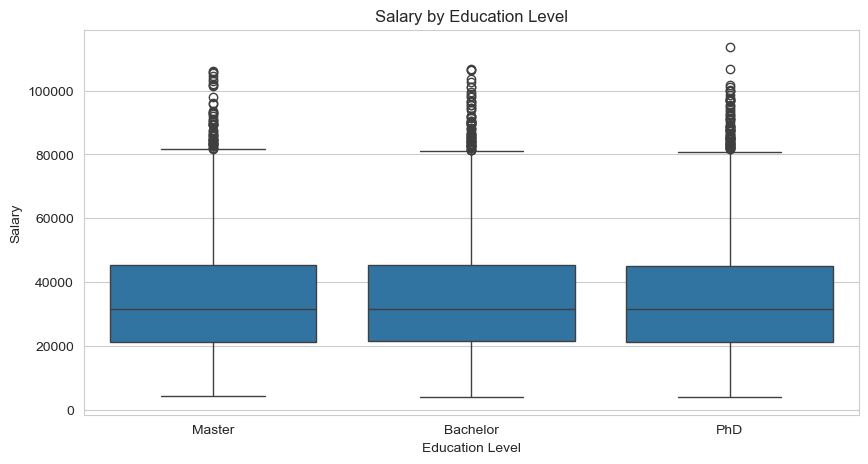

In [32]:
if "education_level" in df.columns and "salary" in df.columns:
    sns.boxplot(data=df, x="education_level", y="salary")
    plt.title("Salary by Education Level")
    plt.xlabel("Education Level")
    plt.ylabel("Salary")
    plt.show()

## Skill Demand Score vs Salary

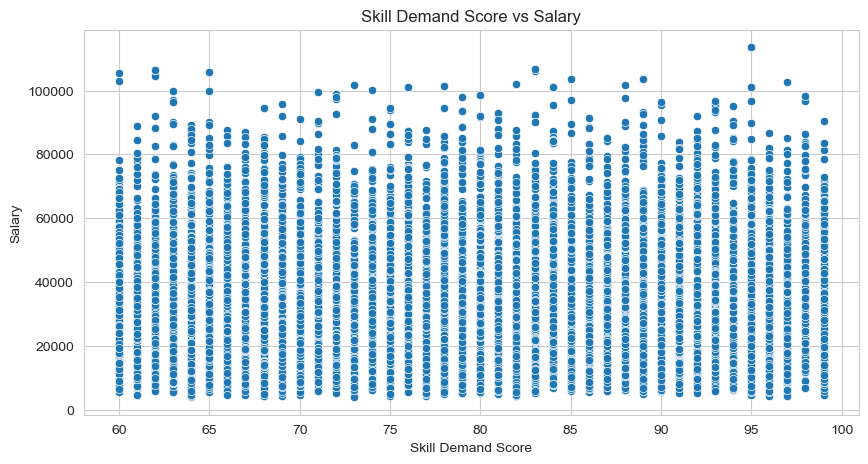

In [33]:
if "skill_demand_score" in df.columns and "salary" in df.columns:
    sns.scatterplot(data=df, x="skill_demand_score", y="salary")
    plt.title("Skill Demand Score vs Salary")
    plt.xlabel("Skill Demand Score")
    plt.ylabel("Salary")
    plt.show()

## Average Salary Over Years

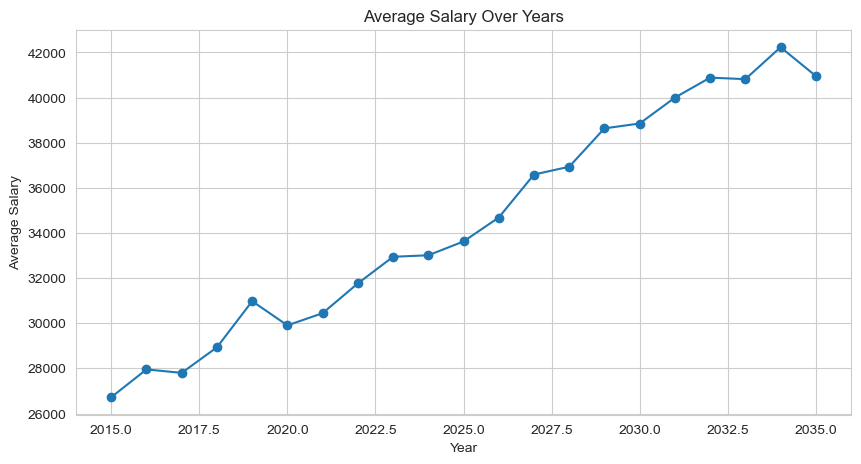

In [34]:
if "year" in df.columns and "salary" in df.columns:
    year_salary = df.groupby("year")["salary"].mean()
    year_salary.plot(marker="o")
    plt.title("Average Salary Over Years")
    plt.xlabel("Year")
    plt.ylabel("Average Salary")
    plt.show()

## Average AI Risk Score Over Years

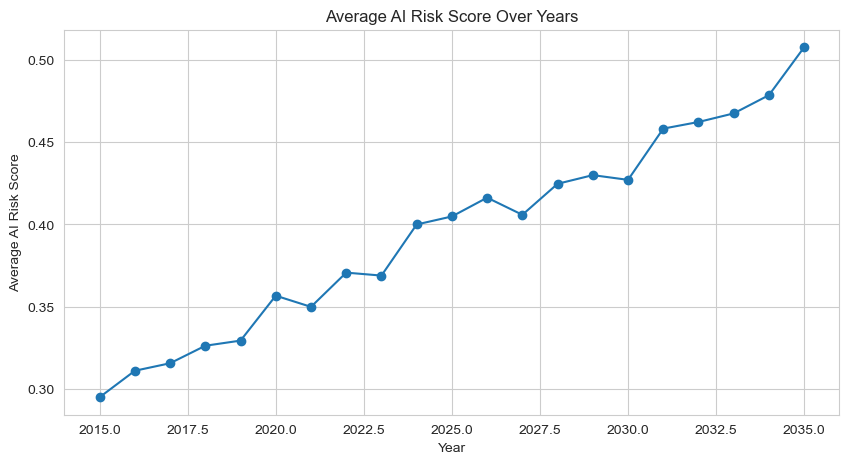

In [35]:
if "year" in df.columns and "ai_risk_score" in df.columns:
    year_risk = df.groupby("year")["ai_risk_score"].mean()
    year_risk.plot(marker="o")
    plt.title("Average AI Risk Score Over Years")
    plt.xlabel("Year")
    plt.ylabel("Average AI Risk Score")
    plt.show()

## Correlation Matrix

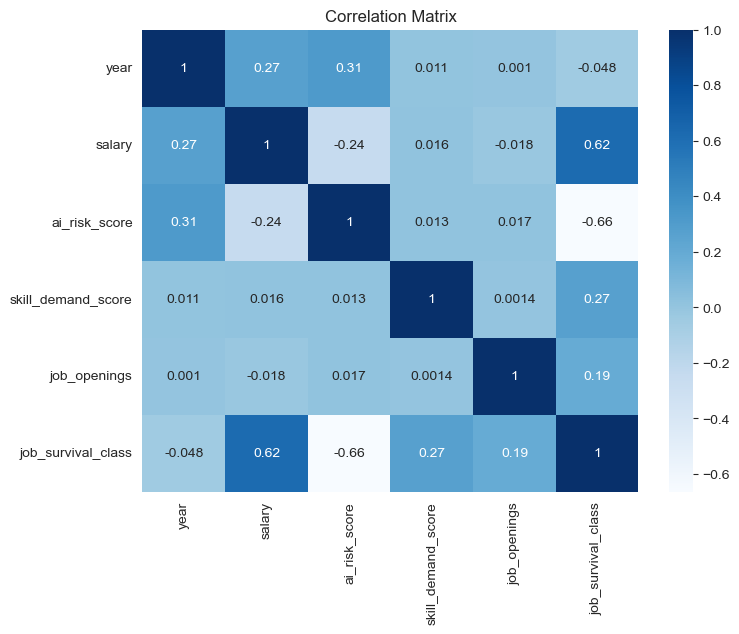

In [36]:
numeric_df = df.select_dtypes(include=np.number)

plt.figure(figsize=(8, 6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Matrix")
plt.show()

## Important Observations

In [37]:
if "salary" in df.columns and "country" in df.columns:
    avg_salary_country = df.groupby("country")["salary"].mean().sort_values(ascending=False)
    print("Average salary by country")
    print(avg_salary_country)

Average salary by country
country
USA          47629.124850
UK           38175.953772
Australia    36914.804937
Canada       35850.323389
Germany      34240.270352
India        13614.547069
Name: salary, dtype: float64


In [38]:
if "job_title" in df.columns and "ai_risk_score" in df.columns:
    avg_risk_job = df.groupby("job_title")["ai_risk_score"].mean().sort_values(ascending=False)
    print("Average AI risk score by job title")
    print(avg_risk_job)

Average AI risk score by job title
job_title
Business Analyst         0.750305
Data Analyst             0.649049
Software Engineer        0.447444
Product Manager          0.400898
Cloud Engineer           0.352584
Data Scientist           0.352498
DevOps Engineer          0.298882
ML Engineer              0.252722
Cybersecurity Analyst    0.250993
AI Researcher            0.150050
Name: ai_risk_score, dtype: float64


In [39]:
if "job_survival_class" in df.columns:
    survival_dist = df["job_survival_class"].value_counts(normalize=True) * 100
    print("Job survival class percentage")
    print(survival_dist)

Job survival class percentage
job_survival_class
1    47.038807
2    41.983310
0    10.977882
Name: proportion, dtype: float64


## Key Findings

- The dataset contains job-related records across multiple countries and years.
- No missing values were detected in the dataset.
- Salary varies across countries, education levels, and experience levels.
- AI risk score differs across job titles.
- Job survival classes may show imbalance, which is important for classification.
- Records from future years should be interpreted carefully because they may represent projections.

## Next Step

The next phase will focus on:

- Data preprocessing
- Encoding categorical variables
- Feature scaling
- Train-test split
- Classification modeling for `job_survival_class`
- Regression modeling for `salary`
- Integrating results into the Streamlit dashboard